In [63]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from empiricaldist import Cdf, Pmf
from utils import decorate, make_joint, plot_contour, normalize


sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 12.1 Penguin Data

In [9]:
df = pd.read_csv('data/penguins_raw.csv').dropna(subset=['Body Mass (g)'])
df['Species2'] = df['Species'].apply(lambda species: species.split()[0])
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,Species2
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.,Adelie
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN,Adelie
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN,Adelie
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN,Adelie
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,2007-11-16,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805,NaN,Adelie


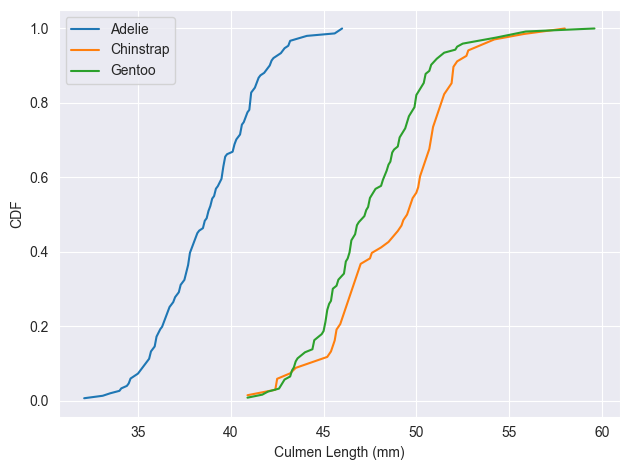

In [16]:
def make_cdf_map(df, colname, by='Species2'):
    cdf_map = {}
    grouped = df.groupby(by)[colname]
    for species, group in grouped:
        cdf_map[species] = Cdf.from_seq(group, name=species)
    return cdf_map


def plot_cdfs(df, colname, by='Species2'):
    """Make a CDF for each species.
    
    df: DataFrame
    colname: string column name
    by: string column name

    returns: dictionary from species name to Cdf
    """
    cdf_map = make_cdf_map(df, colname, by)
    
    for species, cdf in cdf_map.items():
        cdf.plot(label=species, marker='')
    
    decorate(xlabel=colname, ylabel='CDF')

plot_cdfs(df, 'Culmen Length (mm)')

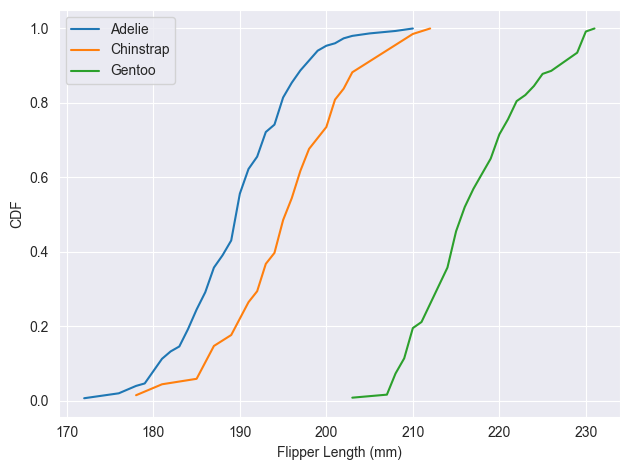

In [17]:
 plot_cdfs(df, 'Flipper Length (mm)')

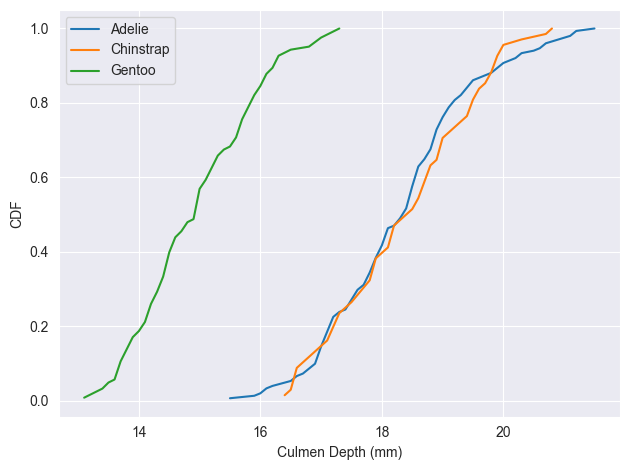

In [18]:
plot_cdfs(df, 'Culmen Depth (mm)')

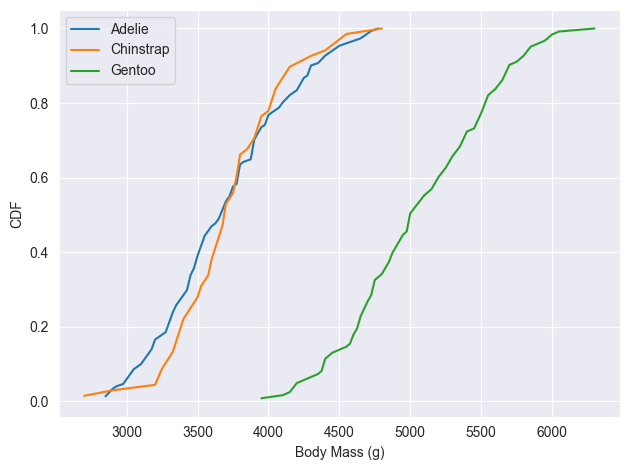

In [19]:
plot_cdfs(df, 'Body Mass (g)')

## 12.2 Normal Models

In [27]:
def make_norm_map(df, colname, by='Species2'):
    norm_map = {}
    grouped = df.groupby(by)[colname]
    for species, group in grouped:
        mean = group.mean()
        std = group.std()
        norm_map[species] = norm(loc=mean, scale=std)
    return norm_map

flipper_map = make_norm_map(df, 'Flipper Length (mm)')
hypos = flipper_map.keys()

data = 193
likelihood = [flipper_map[hypo].pdf(data) for hypo in hypos]

## 12.3 The Update

In [28]:
prior = Pmf(1/3, hypos)
prior

,probs
Adelie,0.333333
Chinstrap,0.333333
Gentoo,0.333333


In [29]:
posterior = prior * likelihood
posterior.normalize()
posterior

,probs
Adelie,0.513860
Chinstrap,0.485589
Gentoo,0.000551


In [31]:
def update_penguin(prior, data, norm_map):
    hypos = prior.qs
    likelihood = [norm_map[hypo].pdf(data) for hypo in hypos]
    posterior = prior * likelihood
    posterior.normalize()
    return posterior

posterior1 = update_penguin(prior, 193, flipper_map)
posterior1

,probs
Adelie,0.513860
Chinstrap,0.485589
Gentoo,0.000551


In [32]:
culmen_map = make_norm_map(df, 'Culmen Length (mm)')
posterior2 = update_penguin(prior, 48, culmen_map)
posterior2

,probs
Adelie,0.001557
Chinstrap,0.474658
Gentoo,0.523785


## 12.4 Naive Bayesian Classification

In [33]:
def update_naive(prior, data_seq, norm_maps: list[dict]):
    """
    Naive Bayesian classifier

    prior: Pmf
    data_seq: sequence of measurements
    norm_maps: sequence of maps from species to distribution

    returns: Pmf representing the posterior distribution
    """

    posterior = prior.copy()
    for data, norm_map in zip(data_seq, norm_maps):
        posterior = update_penguin(posterior, data, norm_map)
    return posterior

norm_maps = [flipper_map, culmen_map]
data_seq = [193, 48]
posterior = update_naive(prior, data_seq, norm_maps)
posterior

,probs
Adelie,0.003455
Chinstrap,0.995299
Gentoo,0.001246


In [40]:
df['Classification'] = "None"

colnames = ['Flipper Length (mm)', 'Culmen Length (mm)']
for i, row in df.iterrows():
    data_seq = row[colnames]
    posterior = update_naive(prior, data_seq, norm_maps)
    df.loc[i, 'Classification'] = posterior.max_prob()


def accuracy(df):
    """Compute the accuracy of classification."""
    valid = df['Classification'].notna()
    same = df['Species2'] == df['Classification']
    return same.sum() / valid.sum()


accuracy(df)

0.9473684210526315

In [42]:
df

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,Species2,Classification
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.,Adelie,Adelie
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN,Adelie,Adelie
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN,Adelie,Adelie
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN,Adelie,Adelie
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,2007-11-16,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805,NaN,Adelie,Adelie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,64,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A2,Yes,2009-11-19,55.8,19.8,207.0,4000.0,MALE,9.70465,-24.53494,NaN,Chinstrap,Chinstrap
340,PAL0910,65,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A1,No,2009-11-21,43.5,18.1,202.0,3400.0,FEMALE,9.37608,-24.40753,Nest never observed with full clutch.,Chinstrap,Chinstrap
341,PAL0910,66,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A2,No,2009-11-21,49.6,18.2,193.0,3775.0,MALE,9.46180,-24.70615,Nest never observed with full clutch.,Chinstrap,Chinstrap
342,PAL0910,67,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A1,Yes,2009-11-21,50.8,19.0,210.0,4100.0,MALE,9.98044,-24.68741,NaN,Chinstrap,Gentoo


## 12.5 Joint Distributions

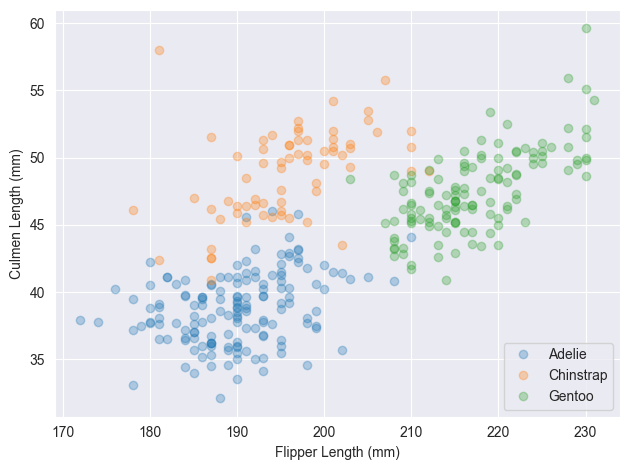

In [50]:
def scatterplot(df, var1, var2):
    grouped = df.groupby('Species2')
    for species, group in grouped:
        plt.plot(
            group[var1], 
            group[var2], 
            label=species, 
            ls="None", 
            marker="o",
            alpha=0.3
        )
    decorate(xlabel=var1, ylabel=var2)

var1 = "Flipper Length (mm)"
var2 = "Culmen Length (mm)"
scatterplot(df, var1, var2)

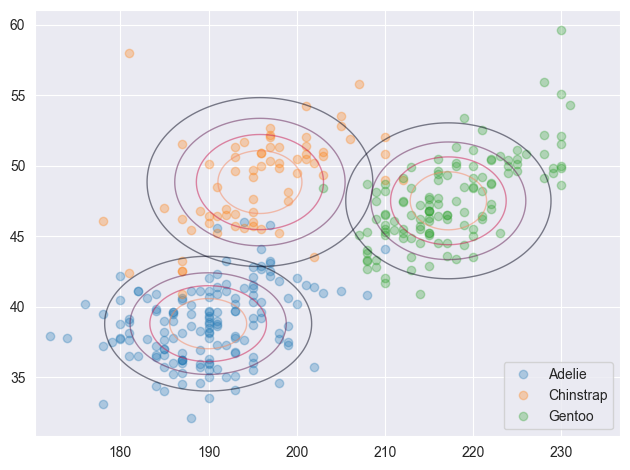

In [57]:
def make_pmf_norm(dist, sigmas=3, n=101):
    mean, std = dist.mean(), dist.std()
    low = mean - sigmas * std
    high = mean + sigmas * std
    qs = np.linspace(low, high, n)
    ps = dist.pdf(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf


joint_map = {}
for species in hypos:
    pmf1 = make_pmf_norm(flipper_map[species])
    pmf2 = make_pmf_norm(culmen_map[species])
    joint_map[species] = make_joint(pmf1, pmf2)

scatterplot(df, var1, var2)
for species in hypos:
    plot_contour(joint_map[species], alpha=0.5)

## 12.6 Multivariate Normal Distribution

In [58]:
features = df[[var1, var2]]
mean = features.mean()
mean

Flipper Length (mm)    200.915205
Culmen Length (mm)      43.921930
dtype: float64

In [59]:
cov = features.cov()
cov

,Flipper Length (mm),Culmen Length (mm)
Flipper Length (mm),197.731792,50.375765
Culmen Length (mm),50.375765,29.807054


In [62]:
def make_multinorm_map(df, colnames):
    multinorm_map = {}
    grouped = df.groupby('Species2')
    for species, group in grouped:
        features = group[colnames]
        mean = features.mean()
        cov = features.cov()
        multinorm_map[species] = multivariate_normal(mean=mean, cov=cov)
    return multinorm_map

multinorm_map = make_multinorm_map(df, [var1, var2])

## 12.7 Visualizing a Multivariate Normal Distribution

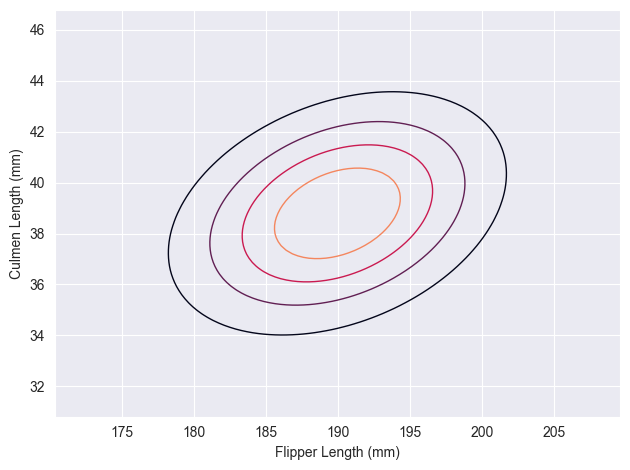

In [64]:
norm1 = flipper_map["Adelie"]
norm2 = culmen_map["Adelie"]

multinorm = multinorm_map['Adelie']
pmf1 = make_pmf_norm(norm1)
pmf2 = make_pmf_norm(norm2)
X, Y = np.meshgrid(pmf1.qs, pmf2.qs)
pos = np.dstack((X, Y))
densities = multinorm.pdf(pos)

joint = pd.DataFrame(densities, columns=pmf1.qs, index=pmf2.qs)
normalize(joint)
plot_contour(joint)
decorate(
    xlabel=var1,
    ylabel=var2
)

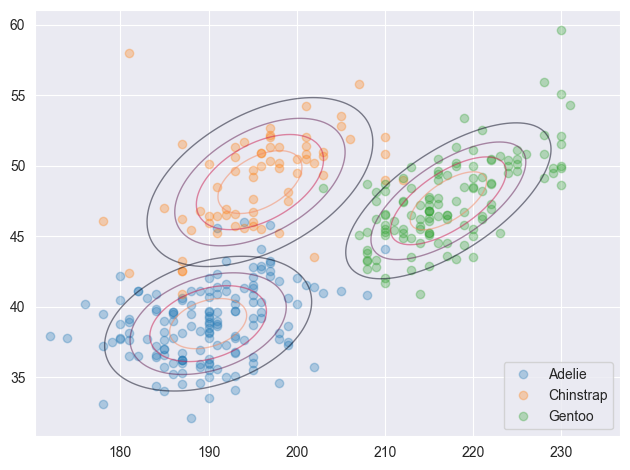

In [65]:
def make_joint(norm1, norm2, multinorm):
    """Make a joint distribution.
    
    norm1: `norm` object representing the distribution of the first feature
    norm2: `norm` object representing the distribution of the second feature
    multinorm: `multivariate_normal` object representing the joint distribution
    """
    pmf1 = make_pmf_norm(norm1)
    pmf2 = make_pmf_norm(norm2)
    X, Y = np.meshgrid(pmf1.qs, pmf2.qs)
    pos = np.dstack((X, Y))
    densities = multinorm.pdf(pos)
    joint = pd.DataFrame(densities, columns=pmf1.qs, index=pmf2.qs)
    return joint


scatterplot(df, var1, var2)

for species in hypos:
    norm1 = flipper_map[species]
    norm2 = culmen_map[species]
    multinorm = multinorm_map[species]
    joint = make_joint(norm1, norm2, multinorm)
    plot_contour(joint, alpha=0.5)

## 12.8 A Less Naive Classifier

In [71]:
data = 193, 48
update_penguin(prior, data, multinorm_map)

,probs
Adelie,0.002740
Chinstrap,0.997257
Gentoo,0.000003


In [73]:
df['Classification'] = "None"

for i, row in df.iterrows():
    data = row[colnames]
    posterior = update_penguin(prior, data, multinorm_map)
    df.loc[i, 'Classification'] = posterior.idxmax()

accuracy(df)

0.9532163742690059